# Taller 4_Alina Elizondo Sánchez

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/heart_disease-UCI.csv', header=0,
                  names= ['edad','sexo','Dolor_toracico_Experimentado',
                  'Presion_Arterial_Reposo','Medicion_Colesterol',
                  'Glucemia_Ayunas','Medicion_Electrocardiografica',
                  'Frecuencia_Cardiaca_Maxima','Angina_Inducida',
                  'Pendiente_ST_Depresion', 'Pendiente_Pico_ST',
                  'Vasos_Sanguineos', 'Talasemia', 'Cardiopatia'])

df.tail()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,edad,sexo,Dolor_toracico_Experimentado,Presion_Arterial_Reposo,Medicion_Colesterol,Glucemia_Ayunas,Medicion_Electrocardiografica,Frecuencia_Cardiaca_Maxima,Angina_Inducida,Pendiente_ST_Depresion,Pendiente_Pico_ST,Vasos_Sanguineos,Talasemia,Cardiopatia
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0



## Instrucciones

0- Preparación de los datos: Crear un diccionario de datos del dataset y convertir las variables que están en inglés en español.

1 – elijan tres combinaciones de tres de las variables, las que ustedes quieran (obviamente habrá variables que se repetirán)

2 – grafiquen los puntos, poniendo un color a los de la categoría con target **cardiopatía** y otro color a los de la categoría **no cardiopatía** **(20 puntos)**

3 – analicen cuan fácil o difícil es, así como el grado de errores que se cometerían, al tratar de separar ambas categorías. Pueden ustedes hacer al respecto un análisis cualitativo o incluso cuantitativo **(30 puntos)**

4 - ahora, lleven a cabo un proceso de reducción de dimensiones, basado en la técnica PCA, respondiendo a las siguientes cuestiones **(50 puntos)**

  4.1 - ¿cual es la función de varianza exhibida por cada una de las CP? Razone la respuesta

  4.2 - en función de los valores de los "loadings" ¿que conclusiones puede establecer sobre la varianza de las diferentes variables originales? Razone la respuesta

  4.3 - si usted reduce el conjunto de variables originales a un conjunto de 3 CP ¿cual es la diferencia con los ejemplos que constituyen sus respuestas al apartado 1 de este trabajo? FIJESE QUE NO SE PIDE COMPARAR RESULTADOS SINO diferencias entre la naturaleza de lo mostrado. Razone la respuesta

# 0 Preparación de los datos:
Crear un diccionario de datos del dataset y convertir las variables que están en inglés en español.

In [ ]:
print('Tipo de datos:\n')
print(df.dtypes)

Tipo de datos:

edad                               int64
sexo                               int64
Dolor_toracico_Experimentado       int64
Presion_Arterial_Reposo            int64
Medicion_Colesterol                int64
Glucemia_Ayunas                    int64
Medicion_Electrocardiografica      int64
Frecuencia_Cardiaca_Maxima         int64
Angina_Inducida                    int64
Pendiente_ST_Depresion           float64
Pendiente_Pico_ST                  int64
Vasos_Sanguineos                   int64
Talasemia                          int64
Cardiopatia                        int64
dtype: object


In [ ]:
diccionario = pd.DataFrame([
    {"Nombre de variable":"edad", "tipo_python":"int64",
     "descripcion": "Edad de la persona en años", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"sexo", "tipo_python":"int64",
     "descripcion": "Sexo de la persona (1 = masculino, 0 = femenino)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Dolor_toracico_Experimentado", "tipo_python":"int64",
     "descripcion": "Dolor torácico experimentado (Valor 1: angina típica, Valor 2: angina atípica, Valor 3: dolor no anginoso, Valor 4: asintomático)", ":tipo_estadistico":"cualitativo"},

     {"Nombre de variable":"Presion_Arterial_Reposo", "tipo_python":"int64",
     "descripcion": "Medición de colesterol de la persona en mg/dl", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"Medicion_Colesterol", "tipo_python":"int64",
     "descripcion": "Medición de colesterol", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"Glucemia_Ayunas", "tipo_python":"int64",
     "descripcion": " Glucemia en ayunas de la persona (>120 mg/dl, 1 = verdadero; 0 = falso)", ":tipo_estadistico:":"cuantitativo"},

    {"Nombre de variable":"Medicion_Electrocardiografica", "tipo_python":"int64",
     "descripcion": "Medición electrocardiográfica", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Frecuencia_Cardiaca_Maxima", "tipo_python":"int64",
     "descripcion": "Medición electrocardiográfica en reposo (0 = normal, 1 = con anomalía de la onda ST-T, 2 = con hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes)", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"Angina_Inducida", "tipo_python":"int64",
     "descripcion": "Angina inducida por el ejercicio (1 = sí; 0 = no)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Pendiente_ST_Depresion", "tipo_python":"int64",
     "descripcion": "Depresión del segmento ST inducida por el ejercicio en relación con el reposo (el valor 'ST' se refiere a las posiciones en el gráfico del ECG.", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Pendiente_Pico_ST", "tipo_python":"float64",
     "descripcion": "Pendiente del segmento ST máximo durante el ejercicio (Valor 1: ascendente, Valor 2: plano, Valor 3: descendente)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Vasos_Sanguineos", "tipo_python":"int64",
     "descripcion": "Número de vasos sanguíneos principales (0-3)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Talasemia", "tipo_python":"int64",
     "descripcion": "Un trastorno sanguíneo llamado talasemia (3 = normal; 6 = defecto fijo; 7 = defecto reversible)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Cardiopatia", "tipo_python":"int64",
     "descripcion": "Cardiopatía (0 = no, 1 = sí)", ":tipo_estadistico":"cualitativo"}


        ])
print('\nDiccionario de datos:\n')

diccionario


Diccionario de datos:



,Nombre de variable,tipo_python,descripcion,:tipo_estadistico,:tipo_estadistico:
0,edad,int64,Edad de la persona en años,cuantitativo,NaN
1,sexo,int64,"Sexo de la persona (1 = masculino, 0 = femenino)",cualitativo,NaN
2,Dolor_toracico_Experimentado,int64,Dolor torácico experimentado (Valor 1: angina ...,cualitativo,NaN
3,Presion_Arterial_Reposo,int64,Medición de colesterol de la persona en mg/dl,cuantitativo,NaN
4,Medicion_Colesterol,int64,Medición de colesterol,cuantitativo,NaN
5,Glucemia_Ayunas,int64,"Glucemia en ayunas de la persona (>120 mg/dl,...",NaN,cuantitativo
6,Medicion_Electrocardiografica,int64,Medición electrocardiográfica,cualitativo,NaN
7,Frecuencia_Cardiaca_Maxima,int64,Medición electrocardiográfica en reposo (0 = n...,cuantitativo,NaN
8,Angina_Inducida,int64,Angina inducida por el ejercicio (1 = sí; 0 = no),cualitativo,NaN
9,Pendiente_ST_Depresion,int64,Depresión del segmento ST inducida por el ejer...,cualitativo,NaN


## 1/2.Combinaciones
Grafiquen los puntos, poniendo un color a los de la categoría con target cardiopatía y otro color a los de la categoría no cardiopatía (20 puntos)

### Primera combinación

In [ ]:
#Dataframe
combinacion_cardiopatia =  pd.DataFrame(dict(Presion = df['Presion_Arterial_Reposo'],
Colesterol = df['Medicion_Colesterol'],
Edad = df["edad"],
Cardiopatia = df['Cardiopatia'],
))


#Gráfico
grafico = px.scatter_3d(combinacion_cardiopatia, x= 'Presion', y='Colesterol', z='Edad', color= 'Cardiopatia',
                        title =  'Distribución de las variables  presión arterial de reposo, medición del colesterol y edad con relación a incidencia la cardiopatía')
grafico.show()

In [ ]:
#Calcular correlación
corr = combinacion_cardiopatia.corr()
corr

,Presion,Colesterol,Edad,Cardiopatia
Presion,1.000000,0.123174,0.279351,-0.144931
Colesterol,0.123174,1.000000,0.213678,-0.085239
Edad,0.279351,0.213678,1.000000,-0.225439
Cardiopatia,-0.144931,-0.085239,-0.225439,1.000000


**Interpretación:**
Los puntos amarillos se representan las personas que representan cardiopatías. Mientras que de color azul, se representan las que no presentan cardiopatías. No se represnta una separación clara.

Desde cierto ángulo, se encuentra un outliner, de una persona que representa cardiopatía, poseee un presión arterial de 115, un colesterol demasisado alto de 564 y edad 67. Donde el principal outliner se haya en el colesterol.


Por otro lado, se encuentra un outliner de una persona con 200 de presion, colesterol de 288, edad 50 años que no presenta cardipatía. Pero, según esos niveles es mejor valorar un chequeo.

La relación entre la presión con la cardiopatía es de -0.14 es una correlación negativa muy baja casi nula.

La relación entre el colesterol y la cardiopatía es de -0.09 es una correlación negativa muy baja casi nula.

La relación entre la edad y la cardiopatía es de -0.23, es una correlación negativa muy baja casi nula.

### Segunda combinación

In [ ]:
#Dataframe
combinacion_cardiopatia2 = pd.DataFrame(dict(Dolor = df['Dolor_toracico_Experimentado'],
Presion = df['Presion_Arterial_Reposo'],
ST_Depresion = df["Pendiente_ST_Depresion"],
Cardiopatia = df['Cardiopatia'],
))


#Gráfico
grafico = px.scatter_3d(combinacion_cardiopatia2,
x='Dolor',  y='Presion',  z='ST_Depresion', color='Cardiopatia', title = 'Distribución entre las variables dolor torácico, presión arterial, ST_Depresión con relación a la cardiopatía',
color_continuous_scale= ["green", "yellow"])
grafico.show()

In [ ]:
#Calcular correlación
corr = combinacion_cardiopatia2.corr()
corr

,Dolor,Presion,ST_Depresion,Cardiopatia
Dolor,1.000000,0.047608,-0.149230,0.433798
Presion,0.047608,1.000000,0.193216,-0.144931
ST_Depresion,-0.149230,0.193216,1.000000,-0.430696
Cardiopatia,0.433798,-0.144931,-0.430696,1.000000


**Interpretación**

Los puntos de color amarillo representan las personas con presencia de cardiopatías y en verde las que no tienen cardiopatías.

Los puntos de color amarillo se sitúan los niveles más altos de presión y ST_Depresión relacionandolos con la presencia de cardiopatías.

Se percibe una separación más o menos clara, en donde los puntos verdes (sin cardiopatías) se tienden a grupar más al lado izquierdo , es decir tienen valores más bajos. Mientras que del lado derecho se visualizan más los puntos amarillos asociados con cardiopatías, poseen los valores más altos con relación al dolor torácico, la presión arterial en reposo y depresión del segmento ST.

Ahora bien, tomando en cuenta la correlación, el dolor torácico se asocia con la cardipatía en un 0.43, lo cual indica una correlación positiva moderada. Es decir, entre más aumenta el dolor torácico, más aumenta el riesgo de presentar cardiopatía.


La presión se asocia con la cardipatía en un -0.14, indicando que es una correlación negativa muy baja. Es decir, la relación no es significativa.


Y la ST_Depresion se asocia con la cardiopatía en un -0.43, mostrando una relación negativa moderada. Es decir, conforme aumenta la presión del segmento ST, la probabilidad de cardiopatía disminuye. Cabe destacar que en la ciencia medica si guardan una relación positiva, donde si aumenta la depresión del segmento, aumenta la probabilidad de cardiopatía.

### Tercera combinación

In [ ]:
#Dataframe
combinacion_cardiopatia3 = pd.DataFrame(dict(Sexo = df['sexo'],
Edad = df['edad'],
Frecuencia = df["Frecuencia_Cardiaca_Maxima"],
Cardiopatia = df['Cardiopatia']
))


#Gráfico
grafico = px.scatter_3d(combinacion_cardiopatia3,
x="Sexo", y="Edad", z="Frecuencia", color="Cardiopatia",
title = 'Distribución entre las variables sexo, edad y frecuencia cardíaca con relación a la cardiopatía',
color_continuous_scale= ["green", "red"],
size="Sexo", size_max=18, symbol="Edad", opacity=0.7 )

# Márgenes
grafico.update_layout(margin=dict(l=0, r=0, b=0, t=0)
)

grafico.show()

In [ ]:
#Calcular correlación
corr = combinacion_cardiopatia3.corr()
corr

,Sexo,Edad,Frecuencia,Cardiopatia
Sexo,1.000000,-0.098447,-0.044020,-0.280937
Edad,-0.098447,1.000000,-0.398522,-0.225439
Frecuencia,-0.044020,-0.398522,1.000000,0.421741
Cardiopatia,-0.280937,-0.225439,0.421741,1.000000


**Interpretación:**
Los símbolos rojos hacen referencia a la presencia de cardiopatía y los verdes a la ausencia de cardiopatía.
Se puede decir que están bastante unidos a un sólo lado del gráfico. No obstante, parece que los símbolos rojos se encuentran más en la parte superior y los verdes en la parte inferior, lo cual permite percibir una cierta separación.

Entre los valores atípicos destaca un punto verde (sin cardiopatía), de un masculino, de 77 años de edad, con una frecuencia cardíaca de 162. Loc ual hay que analizar puesto que para su edad avanzada y su frecuencia cardíaca no presenta cardiopatía.
Asimismo, existe un punto de color rojo(cardiopatía), el cual es un masculino, de 29 años de edad con un afrecuencia cardíaca de 202. Es un caso a analizar, ya que se trata de una persona joven con un valor extremadamente alto en la frecuencia cardíaca y tiene presencia de cardiopatía.

Con respecto a las correlaciones, se encuentra que el sexo guarda una correlación de -0.28 con respecto a la cardiopatía. Esto indica que es una correlación negativa débil, donde ser hombre tiene menor probabilidad de cardiopatía. No obstante, hay que analizar la distribución y representitividad de la muestra.

Por otro lado, la edad correlacionada con la cardiopatía es de -0.22, lo cual sugiere que es una correlación negativa débil, donde la edad no sería tan relevante, aunque en la realidad es relevante, por lo que habría que analizar la muestra.

Y por último, la frecuencia cardiaca tiene una relación de 0.42 con relación a la cardiopatía. Es de cir, es una correlación positiva moderada, donde si la frecuencia cardiaca aumenta, la posibilidad de una cardiopatía se eleva.

## 3.Análisis de grados de errores
Analicen cuan fácil o difícil es, así como el grado de errores que se cometerían, al tratar de separar ambas categorías. Pueden ustedes hacer al respecto un análisis cualitativo o incluso cuantitativo **(30 puntos)**


In [ ]:
def confirmacion(valor, columnas, validacion):
    total = len(validacion)

    for indice, columna in enumerate(columnas):
        indice_may_no = 0
        indice_menor_no = 0

        for i in range(total):
# Mayores al corte y no cardiacos
            if columna[i] > valor:
                if validacion[i] == 0:
                    indice_may_no += 1

# Menores o iguales al corte y no cardiacos
            if columna[i] <= valor:
                if validacion[i] == 0:
                    indice_menor_no += 1

        print('\nColumna\n', indice + 1)
        print('\nCantidad de numeros mayores al corte y no cardiacos es:',indice_may_no)
        print('\n Error: ', (indice_may_no/total)*100)
        print('\nCantidad de numeros menores al corte y no cardiacos',indice_menor_no)
        print('\n Error: ', (indice_menor_no/total)*100)

        print('Total:', total)

# Punto de corte y llamada de variables
valor = 150
a= df['Presion_Arterial_Reposo']
b= df['Medicion_Colesterol']
c= df['edad']
v = df['Cardiopatia']
confirmacion(valor,[a, b,c], v)


Columna
 1

Cantidad de numeros mayores al corte y no cardiacos es: 21

 Error:  6.9306930693069315

Cantidad de numeros menores al corte y no cardiacos 117

 Error:  38.613861386138616
Total: 303

Columna
 2

Cantidad de numeros mayores al corte y no cardiacos es: 136

 Error:  44.884488448844884

Cantidad de numeros menores al corte y no cardiacos 2

 Error:  0.6600660066006601
Total: 303

Columna
 3

Cantidad de numeros mayores al corte y no cardiacos es: 0

 Error:  0.0

Cantidad de numeros menores al corte y no cardiacos 138

 Error:  45.54455445544555
Total: 303


**Interpretación**

Columna 1: Presión arterial en reposo
Mayores al corte: 21
Menores o iguales: 117
La mayoría de personas sin ausencia de cardiopatías, especificamente, 117 personas tienen una presión arterial igual o menor al punto de cohorte de 150. Mientras que 21 personas tienen una presión mayor a 150.
Por ende, la mayoría de personas sin poblemas cardiacos tiene una presión arterial de reposo menor a 150. También se deduce que al existen dos grupos por encima y por debajo del punto de cohorte se puede hacer una separación intermedia, ya que tiene buena distribución, hay datos de ambos lados.


Columna 2: Colesterol
Mayores al corte: 136
Menores:2
La mayoría de personas sin cardiopatías (136) presentan un nivel de colesterol por encima de 150. Mientras que solamente 2 personas presentan un nivel de colesterol por debajo del cohorte. Se puede hacer una separación, pero es muy débil, los grupos no son equilibrados.


Columna 3: Edad
Mayores: 0
Menores: 138
De las 138 personas nadie obviamente supera los 150 años de edad. La separación en nula.


En conclusión, la separación de estas variables es muy díficil. Con un cohorte de 150, algunas variables son nulas de separar (edad). Mientras, si el cohorte se reduce la edad se separaría, pero las otras dos variables (presión y colesterol) no se podrían separar. No hay cohorte que se adapte a las tres variables, ya que todas tienen distribuciones diferentes.


## 4.Proceso de reducción de dimensiones


###   4.1 - ¿Cuál es la función de varianza exhibida por cada una de las CP?

Razone la respuesta

Varianza por componente: [23.06 16.87 15.73 12.98 11.45 10.15  9.78]


Media de las variables estandarizadas [ 0. -0. -0.  0.  0.  0. -0.]

Desviación estándar de las variables estandarizadas [1.27 1.09 1.05 0.95 0.9  0.84 0.83]


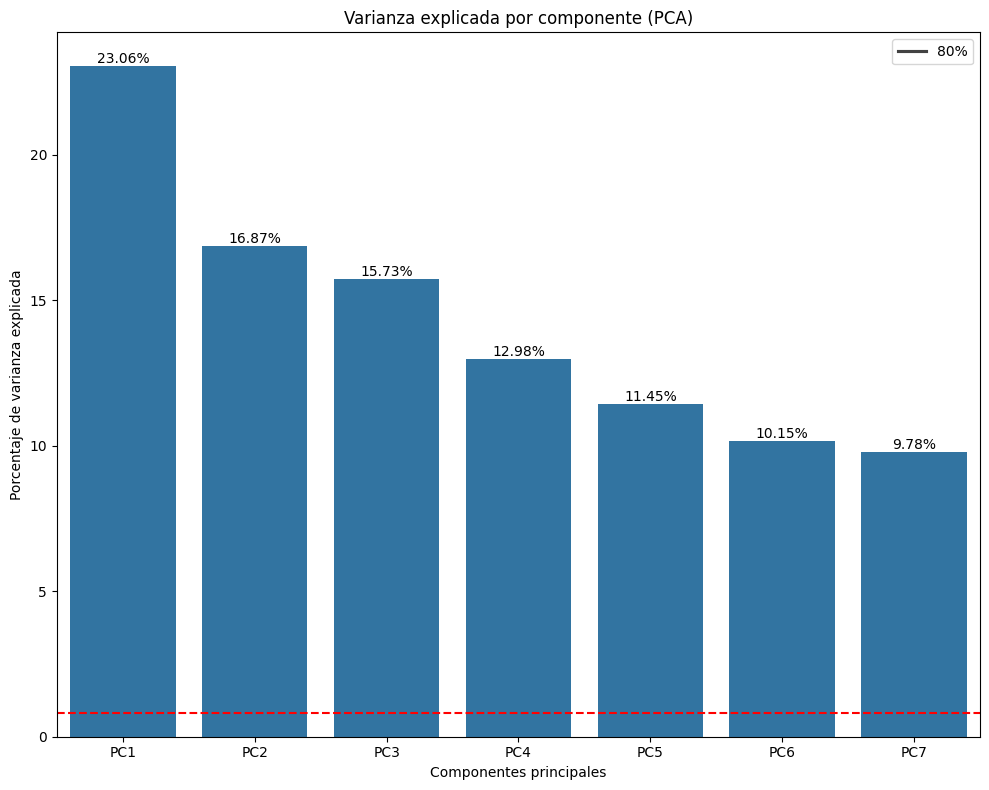

In [ ]:
# Importar librería
from sklearn.preprocessing import StandardScaler

#Definir las variables independientes y dependientes
x =  df.iloc[:,0:7]  # se toman las variables de x
y =  df.iloc[:,-1] # se toma la variable como la y

# Estandarizacion o normalizacion de las variables
x= StandardScaler().fit_transform(x)

# Aplicar PCA para saber el porcentaje de varianza de las componentes
pca = PCA(n_components=None)
componentes_principales =  pca.fit_transform(x)

#Calcular varianza por componente
Varianza = np.round(pca.explained_variance_ratio_* 100, decimals =2)
print ('Varianza por componente:', Varianza)
print('\n')

# Media de las variables estandarizadas
print('Media de las variables estandarizadas', componentes_principales.mean(axis=0).round(2))

# Desviación estándar de las variables estandarizadas
print('\nDesviación estándar de las variables estandarizadas', componentes_principales.std(axis=0).round(2))

#Grafico de barras
componentes= ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']

plt.figure(figsize=(10,8))
ax= sns.barplot(x= componentes, y= Varianza)
plt.ylabel('Porcentaje de varianza explicada')
plt.xlabel('Componentes principales')
ax.bar_label(ax.containers[0], fmt= '%.2f%%')
plt.title('Varianza explicada por componente (PCA)')
plt.xticks(range(0,7))
plt.axhline(y=0.8, color='red', linestyle='--')
plt.legend(['80%'])
plt.tight_layout()
plt.show()

**Interpretación**
En base al anterior análisis de componentes principales (PCA), se obtiene el porcentaje de varianza de cada componente, donde a partir del componente 5, se obtiene el 80% de la varianza. Es decir, con 5 componentes se puede reducir la dimensionalidad mantienen un análisis equilibrado sin perder información importante.


A media de cada componenete es cero, debido a la estandarización o normalización previa.

Por su parte la desviación estándar indica la dispersión de cada componente, en donde el componente PC1 tienen la desviaciónn estándar más grande con un 1.27, mientras que la desviacion estándar de PC7, obtiene la desviación estandar más baja con un 0.83.

###   4.2 - En función de los valores de los "loadings" ¿que conclusiones puede establecer sobre la varianza de las diferentes variables originales? Razone la respuesta

Cargas de las variables (autovectores)                                     PC1       PC2       PC3       PC4  \
edad                           0.695155 -0.042339 -0.039389  0.355417   
sexo                          -0.286908  0.511345 -0.618588  0.094252   
Dolor_toracico_Experimentado  -0.052377  0.452007  0.667629 -0.439679   
Presion_Arterial_Reposo        0.638029  0.286231  0.109271  0.264999   
Medicion_Colesterol            0.580042 -0.458791  0.003953 -0.277452   
Glucemia_Ayunas                0.362827  0.640012  0.070737  0.066364   
Medicion_Electrocardiografica -0.419243 -0.121878  0.507592  0.656611   

                                    PC5  
edad                          -0.168375  
sexo                          -0.167258  
Dolor_toracico_Experimentado  -0.265481  
Presion_Arterial_Reposo       -0.407826  
Medicion_Colesterol            0.214825  
Glucemia_Ayunas                0.670183  
Medicion_Electrocardiografica  0.125009  


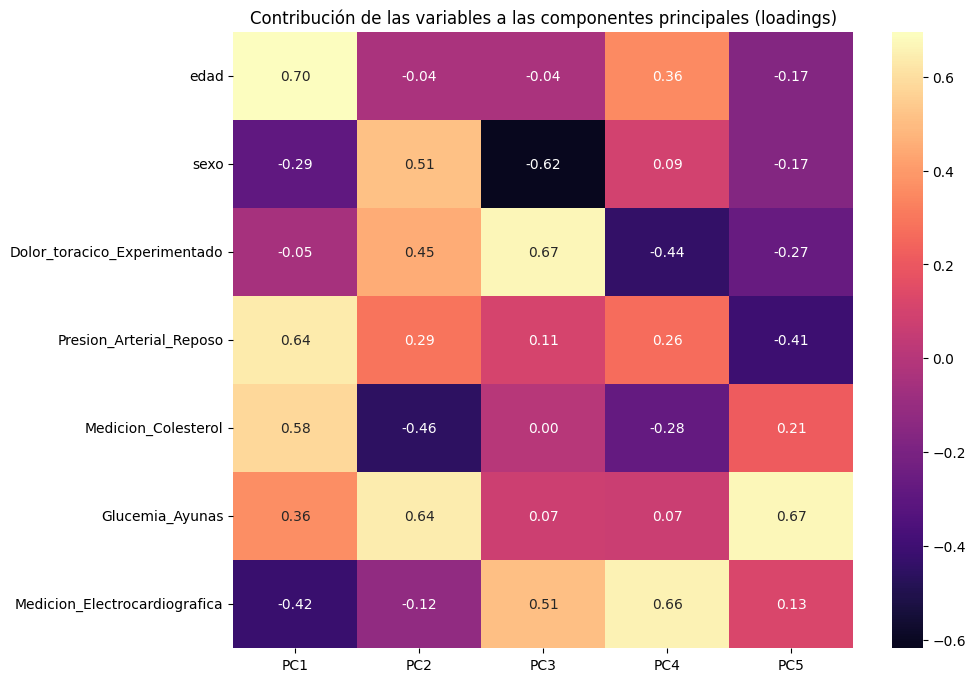

In [ ]:
# Analizar las cargas de los componentes
# Escalar las cargas
loading = pca.components_ * np.sqrt(pca.explained_variance_).reshape(-1, 1)

nombre_variables = df.columns[0:7]
df_loading = pd.DataFrame(loading.T[:, :5], columns= ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], index= nombre_variables)

print('Cargas de las variables (autovectores)',df_loading)

#Visualización de cargas por medio de mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(df_loading, cmap= 'magma', annot= True, center= 0, fmt= '.2f')
plt.title('Contribución de las variables a las componentes principales (loadings)')
plt.show()

**Interpretación**
En este gráfico de calor se puede apreciar los cinco componentes loading.

PC1: Las variables, más relevantes son la edad con un 0.70, la presión arterial con un 0.64 y el colesterol con un 0.58. Es decir, en el PC1, estás variables son las más asociadas con la cardiopatía.

PC2: La variable más relevante es la glucemia en ayunas y el sexo con relación a las cardiopatías.

PC3: Las variables más importantes son el dolor torácico y la medición electrocardiografica.

PC4: Las variables más importantes son la medición electrocardiográfica y la edad.

PC5: Las variables más fundamentales son la glucemia en ayunas y la preción arterial en reposo.


En general dos de las variables que influyen más son la edad en PC1, la glucemia en PC5 y el dolor torácico experimentado en PC3
Y la de menor influencia es la medición del colesterol en PC3



##   4.3 - Si usted reduce el conjunto de variables originales a un conjunto de 3 CP ¿cual es la diferencia con los ejemplos que constituyen sus respuestas al apartado 1 de este trabajo? FIJESE QUE NO SE PIDE COMPARAR RESULTADOS SINO diferencias entre la naturaleza de lo mostrado. Razone la respuesta

### Reducción de componentes

In [ ]:
#Reducir a 3 componentes y visualizar
pca = PCA(n_components=3)
principal_components =  pca.fit_transform(x)

#Creación de un dataframe con los componentes y el target
componentes_principales = pd.DataFrame(principal_components,columns= ['PCA1', 'PCA3', 'PCA5'])
target_cardiopatia = pd.DataFrame(y)

#Concatenar los componentes principales con el target de cardiopatia
componentes_principales = pd.concat([componentes_principales, target_cardiopatia], axis= 1)

# Mostrar los 5 datos luego de la concatenación
componentes_principales.head()

,PCA1,PCA3,PCA5,Cardiopatia
0,1.565737,2.932113,0.570743,1
1,-1.669982,0.409773,0.704535,1
2,-0.682061,-0.432307,0.413274,1
3,-0.894975,-0.110988,-0.050939,1
4,0.729334,-2.489576,0.602089,1


### Gráfico final

In [ ]:
# Dataframe para grafico final
com_final =  pd.DataFrame(dict(PCA1 = componentes_principales['PCA1'],
                          PCA3 =  componentes_principales['PCA3'],
                          PCA5 = componentes_principales['PCA5'],
                          Cardiopatia = componentes_principales['Cardiopatia']))

#Gráfico 3D
grafico_final = px.scatter_3d(com_final, x= 'PCA1', y='PCA3', z='PCA5', color= 'Cardiopatia', symbol= 'Cardiopatia',
                              color_continuous_scale= 'Viridis', opacity=0.8,
                              labels= {'PCA1': 'Edad', 'PCA3': 'Glucemia en Ayunas', 'PCA5': 'Dolor torácico experimentado'},
                              title= 'Distribución de los principales componentes que inciden en la cardiopatía según PCA')
grafico_final.update_traces(marker=dict(size=10, line=dict(width=2)))
grafico_final.show()

**Interpretación**

Con el análisis PCA, se permite encontrar las 3 variables con mayor peso con relación a la cardiiopatía. Mientras que al azar, como en el ejercicio uno se hace por convenienza.
De ahí, la importancia de PCA, que permite obtener información de los datos más precisos.

Tambíén existe más separación de los datos para un mejor análisis en la parte superior con los valores más altos de edad, glucemia y dolor torácico experimentado se encuentran las personas que presentan cardiopatías. Por su parte, en la parte bajo con niveles más bajos se encuentran las persona que no presentan cardiopatías.

#TALLER 4

## Ejercicio 1. Matriz de covarianza
Parte matemática

La matriz de covarianza resume esas relaciones para todas las columnas seleccionadas:

Conv (Y, X)

Responda:

a. Seleccione 5 variables que más se relacionan y calcule la matriz de de covarianza.
b. Muestre la interpretación de los resultados obtenidos

In [ ]:
columnas_seleccionadas =  ['edad', 'Dolor_toracico_Experimentado', 'Glucemia_Ayunas','Medicion_Electrocardiografica','Presion_Arterial_Reposo']

In [ ]:
columnas_covarianza = [c for c in ['edad', 'Dolor_toracico_Experimentado', 'Glucemia_Ayunas','Medicion_Electrocardiografica','Presion_Arterial_Reposo'] if c in df.columns]
Xcov = df[columnas_covarianza].dropna().to_numpy(dtype=float)

matriz_covarianza = np.cov(Xcov, rowvar=False)
cov_df = pd.DataFrame(matriz_covarianza, index=columnas_covarianza, columns=columnas_covarianza)

display(cov_df.round(2))

,edad,Dolor_toracico_Experimentado,Glucemia_Ayunas,Medicion_Electrocardiografica,Presion_Arterial_Reposo
edad,82.48,-0.64,0.39,-0.56,44.50
Dolor_toracico_Experimentado,-0.64,1.07,0.03,0.02,0.86
Glucemia_Ayunas,0.39,0.03,0.13,-0.02,1.11
Medicion_Electrocardiografica,-0.56,0.02,-0.02,0.28,-1.05
Presion_Arterial_Reposo,44.50,0.86,1.11,-1.05,307.59


Interpretación: Mediante esta tabla se puede visualizar cómo varían las variables unas con otras. Por ejemplo, la edad y la glucemia en ayunas, tienen una covarianza positiva de 0.39, lo que significa que a mayor edad aumenta la glucemia en ayunas. Lo mismo sucede entre la edad y la presión arterial en reposo con un 44.50, se puede decir que a mayor edad aumenta la presión arterial en reposo. Es decir, estas covarianzas son directas.


Por otra parte, la medición electrocardiográfica y la edad es de -0.56, lo que indica que a mayor medicióm electrocardiografica tiende a disminuir la edad. Otro caso, es la covarianza entre la presión arterial en reposo y la medición electrocardiográfica es de -1.05. Esto indica que al aumentar la presión arterial en reposo, la medición electrocardiográfica tiende a disminuir. Es decir, estas covarianzas son inversas.

## Ejercicio #2: Calcule las distancias euclidianas y Manhattan entre pacientes, para ello seleccione 4 variables que más se relacionan o considere que más información generen para determinar el objetivo o target y de la interpretación.

In [ ]:
from scipy.spatial.distance import pdist, squareform

variables = [c for c in ['edad', 'Dolor_toracico_Experimentado', 'Glucemia_Ayunas','Medicion_Electrocardiografica'] if c in df.columns]
Xd = df[variables].dropna().head(10).to_numpy(dtype=float)

distancia_euclidiana = squareform(pdist(Xd, metric="euclidean"))
distancia_manhattan = squareform(pdist(Xd, metric="cityblock"))

print("Distancia euclidiana:")
print(np.round(distancia_euclidiana, 2))

print("\nDistancia Manhattan:")
print(np.round(distancia_manhattan, 2))

Distancia euclidiana:
[[ 0.   26.06 22.11  7.42  6.86  6.86  7.35 19.16 11.09  6.24]
 [26.06  0.    4.24 19.03 20.1  20.1  19.05  7.07 15.03 20.  ]
 [22.11  4.24  0.   15.03 16.06 16.06 15.    3.16 11.14 16.06]
 [ 7.42 19.03 15.03  0.    1.41  1.41  1.   12.    4.24  1.41]
 [ 6.86 20.1  16.06  1.41  0.    0.    1.73 13.04  5.48  2.  ]
 [ 6.86 20.1  16.06  1.41  0.    0.    1.73 13.04  5.48  2.  ]
 [ 7.35 19.05 15.    1.    1.73  1.73  0.   12.04  4.36  1.73]
 [19.16  7.07  3.16 12.   13.04 13.04 12.04  0.    8.12 13.04]
 [11.09 15.03 11.14  4.24  5.48  5.48  4.36  8.12  0.    5.1 ]
 [ 6.24 20.   16.06  1.41  2.    2.    1.73 13.04  5.1   0.  ]]

Distancia Manhattan:
[[ 0. 29. 25. 11. 11. 11. 10. 23. 13.  9.]
 [29.  0.  6. 20. 22. 22. 21.  8. 16. 20.]
 [25.  6.  0. 16. 18. 18. 15.  4. 14. 18.]
 [11. 20. 16.  0.  2.  2.  1. 12.  6.  2.]
 [11. 22. 18.  2.  0.  0.  3. 14.  8.  2.]
 [11. 22. 18.  2.  0.  0.  3. 14.  8.  2.]
 [10. 21. 15.  1.  3.  3.  0. 13.  7.  3.]
 [23.  8.  4. 12. 14. 14

Interpretación: La distancia euclidiana tiene movimiento diagonal entre dos puntos. Mientras, la distancia de Manhattan tiene movimiento cardinal, más estructurados, hacia la derecha o izquierda, arriba o abajo.
Ambas poseen ceros en sus diagonales y son robustas en este caso para el análisis epidemiológico.
Su importancia radica en que en este caso se van creado grupos de pacientes que se relacionan entre sí según su edad, dolor torácico experimentado, glucemia en ayunas y medición electrocardiografica. Y que cuando la distancia de estos grupos es más pequeña van a hacer perfiles más similares a las variables previamente elegida.

## Ejercicio #3. Mapa de calor de la matriz de distancia
Una matriz de distancia es simétrica y tiene ceros en la diagonal.
Un mapa de calor ayuda a identificar patrones de similitud visualmente.


Muestre un mapa de calor a partir de la matriz euclidiana resultante del ejercicio anterior y muestre su interpretación.


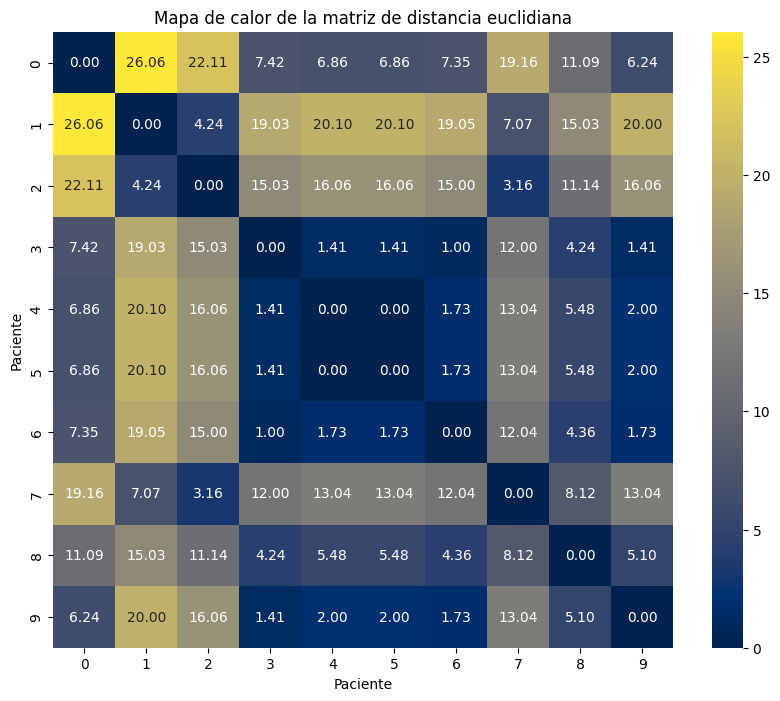

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(distancia_euclidiana, annot= True, fmt= '.2f', cmap='cividis')
plt.title('Mapa de calor de la matriz de distancia euclidiana')
plt.xlabel('Paciente')
plt.ylabel('Paciente')
plt.show()

**Interpretación:** Este gráfico permite observar los pacientes que tienen mayor o menor distancia, de acuerdo a las variables indicadas. De color amarillo intenso, se pueden visualizar los casos donde hay mayor diferencia de características entre los pacientes y en color azul oscuro los que más características tienen en común. En este caso, en particular, se nota que los pacientes tiene bastantes similitudes, con relación, a la edad, dolor toracico experimentado, glucemia en ayunas y medición electrocardiografica.

Tambíen se puede observar que de color azul oscuro, se visualiza la diagonal, que está constituida por ceros, donde la distancia es exactamente la misma, porque es donde se une el mismo paciente.

Algunos otros ejemplos son que la distancia más alejada es el paciente 0 con el paciente 1, con una distancia euclidiana de 26.06, es decir, no tienen mucha relación en cuanto a sus variables. Por su parte, el paciente 3 y el paciente 6 tiene un distancia eucliana de 1.00, lo cuál los hace relativamente cercanos,  con relación a algunas de sus variables descritas.

## Ejercicio 4. Distribución de la variable CHOL (Colesterol)
Una distribución describe la forma en que se reparten los valores de una variable.
No basta con la media; importa también su dispersión, asimetría y presencia de valores extremos.
a. Muestre un gráfico y observe si la distribución parece simétrica o sesgada.
Eso influye en decisiones posteriores sobre escalamiento, transformación o elección de distribuciones teóricas.

<bound method Series.round of count    303.000000
mean     246.264026
std       51.830751
min      126.000000
25%      211.000000
50%      240.000000
75%      274.500000
max      564.000000
Name: Medicion_Colesterol, dtype: float64>


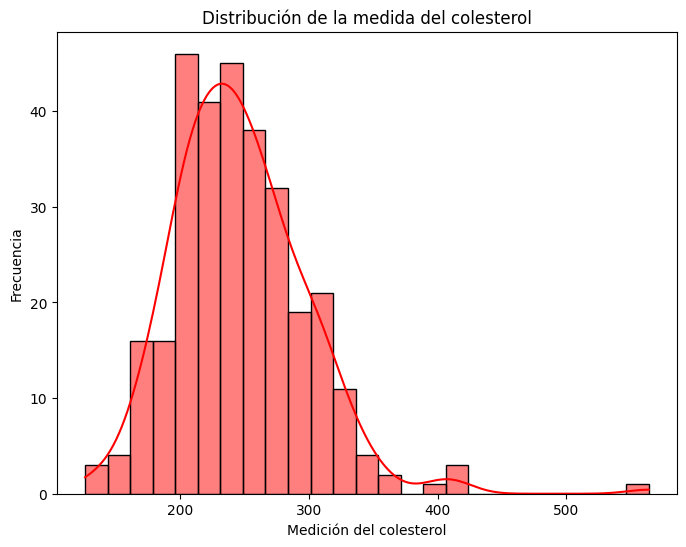

In [ ]:
if 'Medicion_Colesterol' in df.columns:
    x = df['Medicion_Colesterol'].dropna()
    print(x.describe().round)

#Grafico histograma
    plt.figure(figsize=(8, 6))
    sns.histplot(x, kde=True, color= 'red', bins=25)
    plt.title('Distribución de la medida del colesterol')
    plt.xlabel('Medición del colesterol')
    plt.ylabel('Frecuencia')
    plt.show()


**Interpretación**:

Se realizaron 303 tomas de colesterol.

El promedio de colesterol es de 246.26

La desviación estándar es de 51.83

La glucosa mínima es de 126 y la máxima es de 564.

Un 25% de las medidas de glucosa es de 211.00, un 50% o la mitad tiene una glucosa de 240.00 y un 75% es 274.50


Del gráfico, se puede visualizar que existen valores atípicos a la izquierda, tales como, valores superiores a los 400 y 500.
Tal como lo sugieren los datos la desviación es menor que el promedio, lo cual indica que existe bastante concentración  del colesterol entre los 200 y 280 aproximadamente.

La distribución tiene una curva en forma de campana, lo que sugiere una distribución normal. Asimismo, es simétrica, ya que está centrada a la media de 246.26 y ambas colas son casi similares, de no ser por esos valores atípicos.

## Ejercicio #5. Ajuste comparativo de distribuciones
Variables positivas y asimétricas pueden ajustarse mejor a una distribución gamma que a una normal.

a. Muestre el ajuste de la distribución seleccione una variable
Compara visualmente las curvas y revisa los p-values de K-S.
La interpretación no debe quedarse solo en el número: también importa la plausibilidad clínica.

=============NORMAL=================:
mu: 54.37
sigma 9.07
pvalue: 0.0556

===============GAMMA:============
forma: 34.05
Escala: 1.6
pvalue: 0.0096


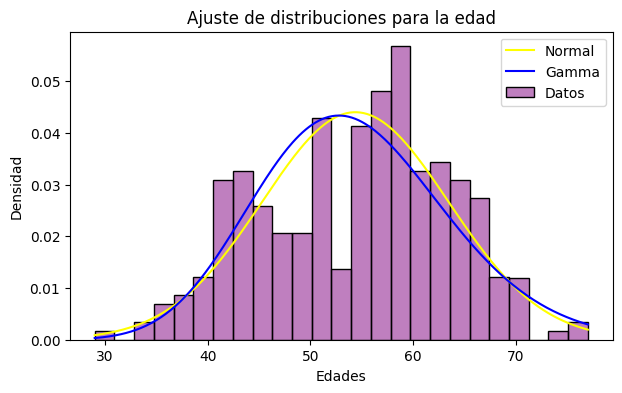

In [ ]:
#Importación
from scipy import stats
from scipy.spatial.distance import squareform, pdist

columnas_seleccionadas =  ['edad', 'Dolor_toracico_Experimentado', 'Glucemia_Ayunas','Medicion_Electrocardiografica','Presion_Arterial_Reposo']
# Variable evaluada
variable = 'edad' if 'edad' in df.columns else columnas_seleccionadas[0]
x = df[variable].dropna().to_numpy(dtype=float)

#Ajuste normal
mu, sigma = stats.norm.fit(x)

#Ajuste de gamma
x_pos = x[x > 0]
shape, loc, scale = stats.gamma.fit(x_pos, floc=0)

#Comparación de normal y gamma mediante estadístico KS
ks_norm = stats.kstest(x, "norm", args=(mu, sigma))
ks_gamma = stats.kstest(x_pos, "gamma", args=(shape, loc, scale))

#Mostrar
print('=============NORMAL=================:')
print('mu:',  round(mu, 2))
print('sigma', round(sigma, 2))
print('pvalue:', round(ks_norm.pvalue, 4))
print('\n===============GAMMA:============' )
print('forma:', round(shape, 2))
print('Escala:', round(scale, 2))
print('pvalue:', round(ks_gamma.pvalue, 4))

#Visualización
plt.figure(figsize=(7,4))
sns.histplot(x_pos, stat='density', color = 'purple', bins=25, alpha=0.5, label='Datos')
xx = np.linspace(x_pos.min(), x_pos.max(), 300)
plt.plot(xx, stats.norm.pdf(xx, mu, sigma), label='Normal', color = 'yellow')
plt.plot(xx, stats.gamma.pdf(xx, shape, loc=loc, scale=scale), label='Gamma', color = 'blue')
plt.legend()
plt.title(f'Ajuste de distribuciones para la edad')
plt.xlabel('Edades')
plt.ylabel('Densidad')
plt.show()

**Interpretación:** El p-value del ajuste normal es de 0.0556 > 0.05. Es deicr, no existe suficientemente evidencia para rechazar la hipótesis nula con relación a un adistribución normal. Por otra parte, la distribución gamma, posee un p-value de0.0096 < 0.05, lo cual inidca que se rechaza la hipotesis de que los datos poseen una distribución gamma.
En otras palabras, el mejor ajuste en este caso es el normal.

=============NORMAL=================:
mu: 131.62
sigma 17.51
pvalue: 0.0035

===============GAMMA:============
forma: 58.63
Escala: 2.24
pvalue: 0.0196


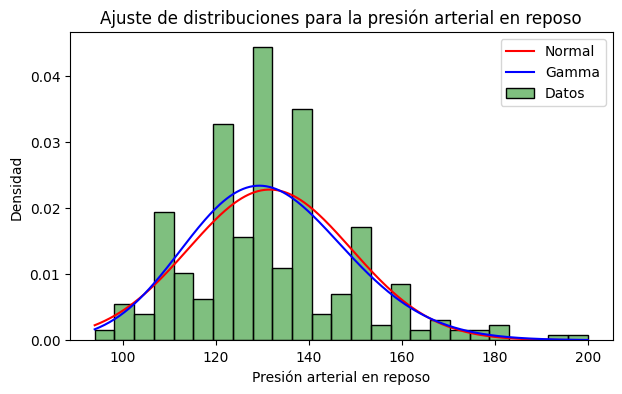

In [ ]:
#Importación
from scipy import stats
from scipy.spatial.distance import squareform, pdist

columnas_seleccionadas =  ['edad', 'Dolor_toracico_Experimentado', 'Glucemia_Ayunas','Medicion_Electrocardiografica','Presion_Arterial_Reposo']
# Variable evaluada
variable = 'Presion_Arterial_Reposo' if 'Presion_Arterial_Reposo' in df.columns else columnas_seleccionadas[0]
x = df[variable].dropna().to_numpy(dtype=float)

#Ajuste normal
mu, sigma = stats.norm.fit(x)

#Ajuste de gamma
x_pos = x[x > 0]
shape, loc, scale = stats.gamma.fit(x_pos, floc=0)

#Comparación de normal y gamma mediante estadístico KS
ks_norm = stats.kstest(x, "norm", args=(mu, sigma))
ks_gamma = stats.kstest(x_pos, "gamma", args=(shape, loc, scale))

#Mostrar
print('=============NORMAL=================:')
print('mu:',  round(mu, 2))
print('sigma', round(sigma, 2))
print('pvalue:', round(ks_norm.pvalue, 4))
print('\n===============GAMMA:============' )
print('forma:', round(shape, 2))
print('Escala:', round(scale, 2))
print('pvalue:', round(ks_gamma.pvalue, 4))
plt.figure(figsize=(7,4))
sns.histplot(x_pos, stat='density', color = 'green', bins=25, alpha=0.5, label='Datos')
xx = np.linspace(x_pos.min(), x_pos.max(), 300)
plt.plot(xx, stats.norm.pdf(xx, mu, sigma), label='Normal', color = 'red')
plt.plot(xx, stats.gamma.pdf(xx, shape, loc=loc, scale=scale), label='Gamma', color = 'blue')
plt.legend()
plt.title(f'Ajuste de distribuciones para la presión arterial en reposo')
plt.xlabel('Presión arterial en reposo')
plt.ylabel('Densidad')
plt.show()

**Interpretación:** El p-value del ajuste normal es de 0.0035 < 0.05. Es decir, se rechaza la hipótesis nula con relación a un adistribución normal. Por otra parte, la distribución gamma, posee un p-value de 0.0196 < 0.05, lo cual indica que se rechaza la hipotesis de que los datos poseen una distribución gamma.  


En otras palabras, ambos ajuste son menores a 0.05. No obstante de los dos, la distribución gamma al ser mayor el p-value, muestra un ajuste mucho más eficiente y ´pausible para esta variable positiva y asimétrica.

In [ ]:
print(df['Glucemia_Ayunas'].unique())
print (df['edad'].unique())
print (df['Presion_Arterial_Reposo'].unique())


[1 0]
[63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77]
[145 130 120 140 172 150 110 135 160 105 125 142 155 104 138 128 108 134
 122 115 118 100 124  94 112 102 152 101 132 148 178 129 180 136 126 106
 156 170 146 117 200 165 174 192 144 123 154 114 164]


## Ejercicio 6. Preparación de datos para entrenamiento
Antes de entrenar un modelo, es necesario separar predictores y objetivo, imputar faltantes y escalar variables numéricas.

a. Muestre los datos de entrenamiento y test (prueba) resultado obtenido
La preparación es parte del modelo, no un paso accesorio.
Un preprocesamiento incorrecto puede introducir fuga de información y volver engañosos los resultados.

In [ ]:
#Importaciones
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Target del dataset (variable objetivo)
target= 'Cardiopatia'

if target is None:
    print('No se detectó la variable objetivo. Revisa el nombre de la columna en tu dataset.')
else:
    X_df = df.drop(columns=[target])
    y = df[target]

    variables_numericas = X_df.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X_df.select_dtypes(exclude=np.number).columns.tolist()

#Preprocesamiento
    preprocesamiento = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), variables_numericas),
        ("cat", Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ]), variables_categoricas)
    ], remainder='drop')

#Entrenanniento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y, test_size=0.25, random_state=42, stratify=y
    )
#Mostrar datos de entrenamiento y test
    print('Entrenamiento:', X_train.shape)
    print('Prueba:', X_test.shape)

Entrenamiento: (227, 13)
Prueba: (76, 13)


**Interpretación:**
Se obtiene una dimensión de 227 registros de entrenamiento y 13 columnas predictoras.
Los datos de prueba generados son 76 registros de prueba y 13 columnas predictoras que permiten hacer la prueba para luego poder generalizar los resultados del modelo.
En otras palabras, este es un proceso donde su función es  ayudar a que el algoritmo aprenda patrones a partir de los datos uministrados.



## Ejercicio 7. Modelo base con regresión logística
La regresión logística modela la probabilidad de una clase binaria y es una referencia importante por su equilibrio entre simplicidad e interpretabilidad.



a. Desarrolle un modelo con regresión logística  utilizando:
Accuracy
Precision
Recall
F1
AUC
Nota: No se quede solo con accuracy.
En problemas de salud, recall, precision y AUC suelen ser mucho más informativos.

In [ ]:
#Importaciones
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#Definición de pipeline
if target is not None:
    pipe = Pipeline([
        ('prep', preprocesamiento),
        ('model', LogisticRegression(max_iter=500))
    ])

#Entrenamiento
    pipe.fit(X_train, y_train)

#Prediciciones y probabilidades
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

#Evaluación
    print('Accuracy (predicciones correctas):', round(accuracy_score(y_test, y_pred), 2))
    print('Precision (precisión):', round(precision_score(y_test, y_pred), 2))
    print('Recall (sensibilidad):', round(recall_score(y_test, y_pred), 2))
    print('F1 (media entre precisión y sensibilidad):', round(f1_score(y_test, y_pred), 2))
    print('AUC (área bajo la curva ROC):', round(roc_auc_score(y_test, y_prob), 2))

Accuracy (predicciones correctas): 0.76
Precision (precisión): 0.74
Recall (sensibilidad): 0.85
F1 (media entre precisión y sensibilidad): 0.8
AUC (área bajo la curva ROC): 0.85


**Interpretación:**
Seguidamente, luego del entrenamiento, se prosigue con métricas iniciales de clasificación.
Se indica que un 76% de las predicicones (positivos y negativos)son correctas, con una precisión de 74% y una sensiblidad de 85%.
Además, la media entre la precisión y la sensibilidad es de 80%.
Y el área bajo la curva ROC  es de 85%, lo cual indica que resume bastante bien la discriminación de un clasificador.
Por lo cual, se concluye que el modelo posee un buen desempeño.

## Ejercicio 8. Comparación de modelos y validación cruzada
La validación cruzada ayuda a estimar mejor la capacidad de generalización.
El ajuste de hiperparámetros busca configuraciones más adecuadas del modelo.

a. En este ejercicio debe integrar la preparación, entrenamiento, validación, comparación e interpretación de al menos los "tres" modelos vistos en la tutoría #4.


LogisticRegression (Regresión logística) AUC media: 0.8901
DecisionTree (árbol de decisión) AUC media: 0.7252
RandomForest (bosque aleatorio) AUC media: 0.9032
Mejores parámetros: {'modelo__max_depth': 3, 'modelo__n_estimators': 200}
AUC en test: 0.8711


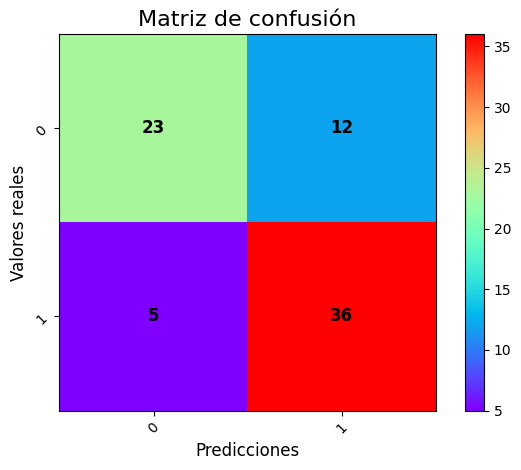

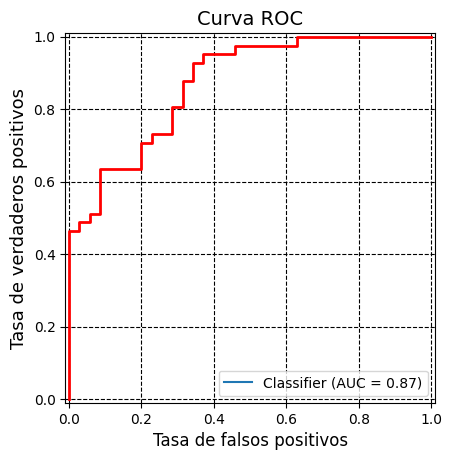

In [ ]:
#Importaciones
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

#Definición de modelos
if target is not None:
    models = {
        'LogisticRegression (Regresión logística)': Pipeline(
            [("prep", preprocesamiento), ("model", LogisticRegression(max_iter=5000))]
        ),
        'DecisionTree (árbol de decisión)': Pipeline(
            [("prep", preprocesamiento), ("model", DecisionTreeClassifier(random_state=42))]
        ),
        'RandomForest (bosque aleatorio)': Pipeline(
            [("prep", preprocesamiento), ("model", RandomForestClassifier(random_state=42))]
        ),
    }

#Validadción cruzada
    validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for nombre, modelo in models.items():
        puntos_auc = cross_val_score(modelo, X_df, y, cv=validacion_cruzada, scoring="roc_auc")
        print(nombre, 'AUC media:', round(puntos_auc.mean(), 4))

    rf_pipe = Pipeline([('Preparacion', preprocesamiento), ('modelo', RandomForestClassifier(random_state=42))])

# Ajuste de hiperparámetros
    param_grid = {
        "modelo__n_estimators": [100, 200],
        "modelo__max_depth": [3, 5, None],
    }

    busqueda= GridSearchCV(rf_pipe, param_grid=param_grid, cv=validacion_cruzada, scoring="roc_auc", n_jobs=-1)

    busqueda.fit(X_train, y_train)

#Resultados del mejor parámetro
    print("Mejores parámetros:", busqueda.best_params_)

    best_model = busqueda.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    print("AUC en test:", round(roc_auc_score(y_test, y_prob), 4))

#Visualización
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap= 'rainbow')
    plt.title('Matriz de confusión', fontsize= 16)
    plt.xlabel('Predicciones',fontsize= 12)
    plt.ylabel('Valores reales', fontsize= 12)
    for text in disp.text_.ravel():
        text.set_color('black')
        text.set_fontsize(12)
        text.set_fontweight('bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

    print('\n')

    roc_disp = RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title('Curva ROC', fontsize= 14)
    plt.xlabel('Tasa de falsos positivos', fontsize= 12)
    plt.ylabel('Tasa de verdaderos positivos', fontsize= 13)
    roc_disp.line_.set_color('red')
    roc_disp.line_.set_linewidth(2)
    plt.grid(True, linestyle= 'dashed', color= 'black')
    plt.show()

**Interpretación:**
La regresión logística AUC media con un 0.8901 discrimina bien entre las clases.

Un árbol de decisión de AUC media de 0.7252 es regular, pero pierde capacidad para distinguir entre clases.

El bosque aleatorio AUC media de 0.9032, es mucho mejor que los anteriores, reduce el sobreajuste y tiene mayor capacidad de distinguir entre clases.

De acuerdo con los mejores parámetros, el modelo de mayor profundidad es 3, 'on un número estimador de 200.

El AUC del test es de 0.8711, lo cual suguiere que a partir de ese nivel los modelos son buenos. No obstante, el mejor modelo a elegir es el RandomForest (bosque aleatorio), ya que este obtuvo la mejor calificación de la prueba.

En base a esta matriz de confusión se obtiene que existen 23 verdaderos negativos, 12 falsos positivos, 5 falsos negativos y 36 verdaderos positivos.
Es decir, los 23 verdaderos negativos y los 36 verdaderos negativos están bien clasificados. No obstante, los 12 falsos positivos y 5 falsos negativos, están mal clasificados.

En el gráfico área bajo la curva se visualiza, donde se pueden visualizar los modelos. La regresión lineal se ve que esta por encima de 0.8, se mantiene de forma ascendente e irregular. El árbol de decisión se ubica entre 0.6 y 0.8, es ascendente e iiregular. Por último, el bosque aleatorio, esta por encima de 0.9, se mantiene con una línea estable.

## Preguntas finales del Taller#4

Preguntas finales para reflexión del taller #4, responda:

¿Qué aprendiste matemáticamente sobre el dataset?
Aprendí sobre la importancia de la covarianza para conocer las relaciones entre variables, lo cual es importante, por ejemplo, para conocer las causas que más se asocian con una enfermedad. Asimismo, la distancia Euclidiana y la Manhattan, son esenciales para crear estratos en las poblaciones, lo cual es vital en análisis epidemiológicos. Igualmente, el ajuste es fundamental, ya que dependiendo de los datos puede ser mejor utilizar el ajuste normal o el gamma. De hecho, eso se comprobó, porque para la variable edad el ajuste mejor resultó ser el normal, pero para la presión arterial en reposo, el mejor fue el gamma.



¿Qué relaciones estadísticas te parecieron más relevantes?
El comportamiento entre el promedio y la desviación estándar, si este último es mayor los datos presentan mayor variabilidad.
Esto es vital para conocer el comportamiento de la representatividad de la población.



¿Cuál modelo mostró mejor rendimiento?
El modelo bosque aleatorio (RandomForest) fue el que mostró mejor rendimiento, ya que obtuvo la mejor calificación luego de las pruebas realizadas y demostró que reduce el sobreajuste y tiene mayor capacidad de distinguir entre clases.

## Referencias

Plotly. (s.f.) 3d scatter plots. https://plotly.com/python/3d-scatter-plots/

Suárez Benson M. (2025).  Análisis, manipulación de datos y entrenamiento de modelos. [Material complementario]


Suárez Benson M. (2025). Funciones matemáticas. [Material complementario]